In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score
from prettytable import PrettyTable

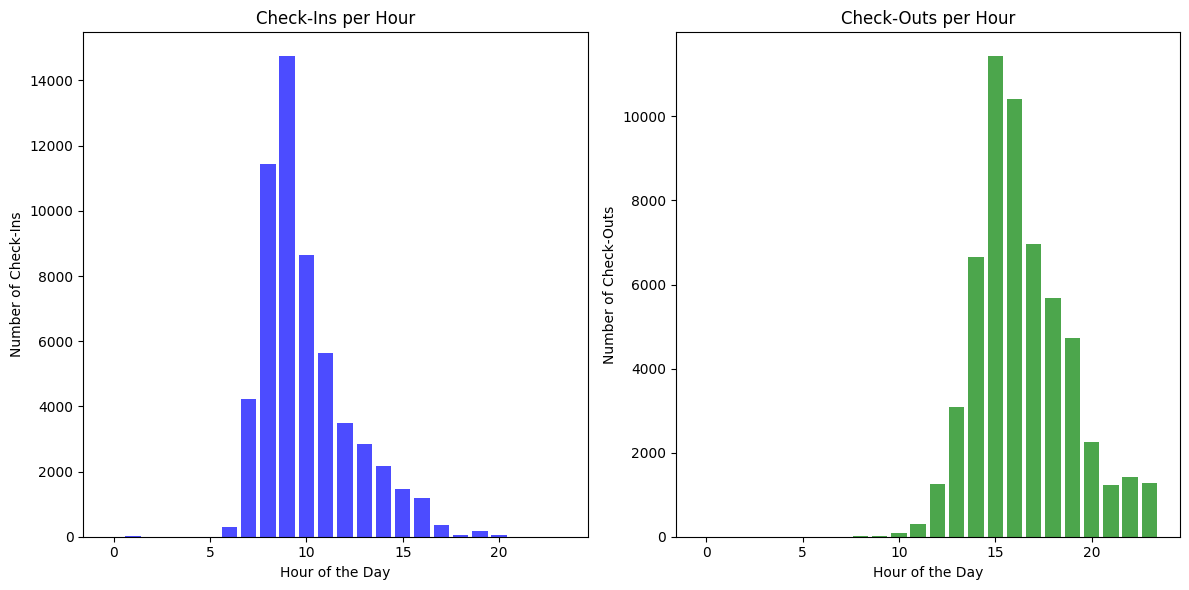

In [6]:
# Load dataset
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3328_wahetnoor'))
csv_file = '3228_wahetnoor_K_means_clustring_result.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

DSet = pd.read_csv(absolute_path)

# Count check-ins per hour
check_in_counts = DSet['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = DSet['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()





Get the optimal number of cluster for GMM model

In [7]:

# Extract features for clustering
features = DSet[['CheckInMinutes', 'CheckOutMinutes']].values

# this function to get the optimal gmm clusters
def optimal_gmm_clusters(features):
    aic = []
    bic = []
    silhouette_scores = []
    n_components_range = range(2, 15) # set the range of clusters from 2 to 15
    
    for n_components in n_components_range:
        # Aplly GMM 
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        #gmm.fit(features)
        gmm_labe = gmm.fit_predict(features)
        #print(" aic clsuter no. ", n_components ," aic value ", aic )
        #print(" bic clsuter no. ", n_components ," bic value ", bic )
        aic.append(gmm.aic(features))
        bic.append(gmm.bic(features))
        silhouette_avg = silhouette_score(features, gmm_labe)
        print(f"Silhouette Score: {silhouette_avg}",n_components)
        silhouette_scores.append(silhouette_avg)
    
    optimal_Clusters = n_components_range[np.argmax(silhouette_scores)]
    #print('The optimal number of clusters for GMM',optimal_Clusters )
    optimal_aic = n_components_range[np.argmin(aic)]
    optimal_bic = n_components_range[np.argmin(bic)]
    
    return optimal_aic, optimal_bic, optimal_Clusters

optimal_aic, optimal_bic,optimal_Clusters = optimal_gmm_clusters(features)
print(f"Optimal number of clusters (AIC): {optimal_aic}")
print(f"Optimal number of clusters (BIC): {optimal_bic}")
print(f"Optimal number of clusters Silhouette score: {optimal_Clusters}")

Silhouette Score: 0.5077506349250238 2
Silhouette Score: 0.3888054344767232 3
Silhouette Score: 0.30979109378077374 4
Silhouette Score: 0.3287652514440716 5
Silhouette Score: 0.3040088565406952 6
Silhouette Score: 0.32658910782770484 7
Silhouette Score: 0.3220030217702745 8
Silhouette Score: 0.33856695375628865 9
Silhouette Score: 0.2081627172590809 10
Silhouette Score: 0.22167216748658644 11
Silhouette Score: 0.22160110833318564 12
Silhouette Score: 0.15499880936088029 13
Silhouette Score: 0.13509651551249746 14
Optimal number of clusters (AIC): 13
Optimal number of clusters (BIC): 13
Optimal number of clusters Silhouette score: 2


Apply GMM with the optimal number of clusters

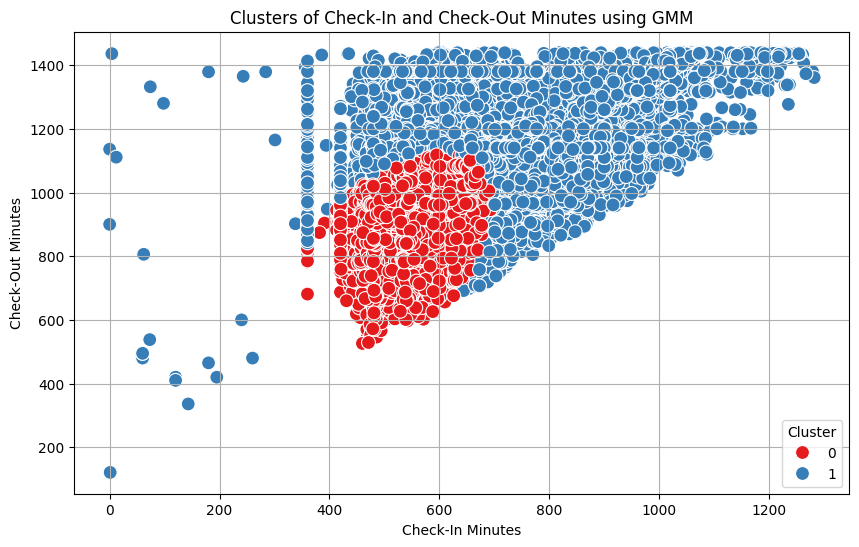

In [8]:
# Use the optimal number of clusters 
n_clusters = optimal_Clusters 

gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(features)

# Add GMM labels to the DataFrame
DSet['Cluster'] = gmm_labels

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CheckInMinutes', y='CheckOutMinutes', hue='Cluster', data=DSet, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Minutes using GMM')
plt.xlabel('Check-In Minutes')
plt.ylabel('Check-Out Minutes')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Calculate the variance and MSE

In [9]:
def calculate_variance_and_mse(df, cluster_col, feature_cols):
    variances = []
    mses = []
    for cluster in df[cluster_col].unique():
        cluster_data = df[df[cluster_col] == cluster][feature_cols].values
        centroid = cluster_data.mean(axis=0)
        variance = np.mean(np.linalg.norm(cluster_data - centroid, axis=1)**2)
        mse = mean_squared_error(cluster_data, [centroid] * len(cluster_data))
        variances.append(variance)
        mses.append(mse)
    return variances, mses
GMM_variance, GMM_mse = calculate_variance_and_mse(DSet, 'Cluster', ['CheckInMinutes', 'CheckOutMinutes'])
print("GMM Variance:", GMM_variance)
print("GMM MSE:", GMM_mse)

GMM Variance: [37333.807656466255, 10567.143926508483]
GMM MSE: [18666.903828233124, 5283.571963254268]


Variance in minutes: [193.21958404 102.79661437]
MSE in minutes: [136.62687813  72.68818311]


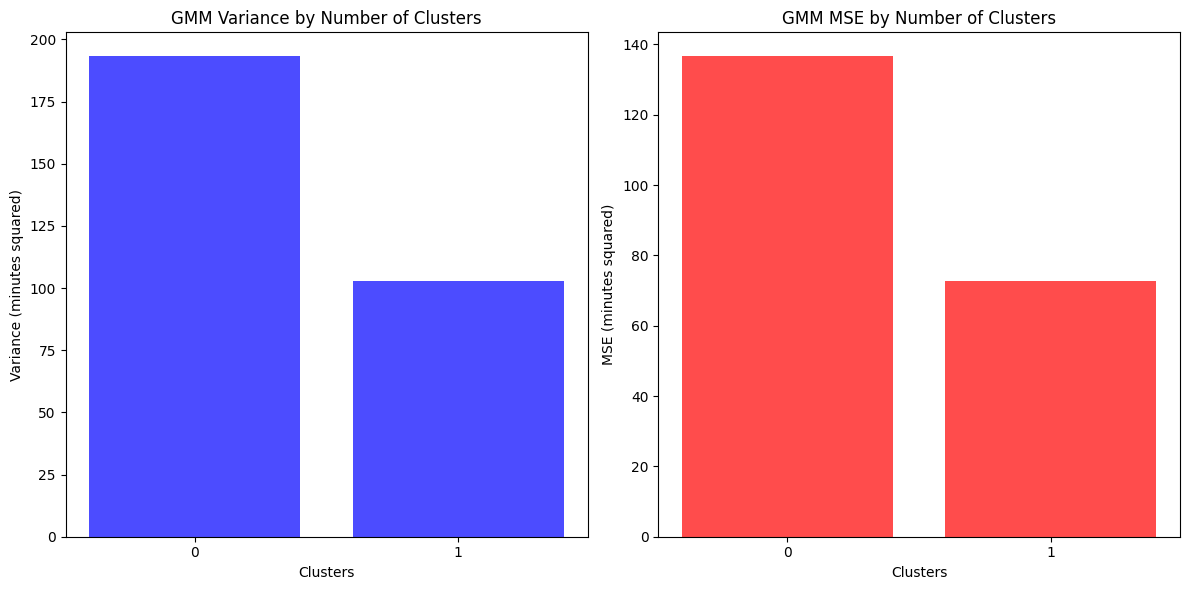

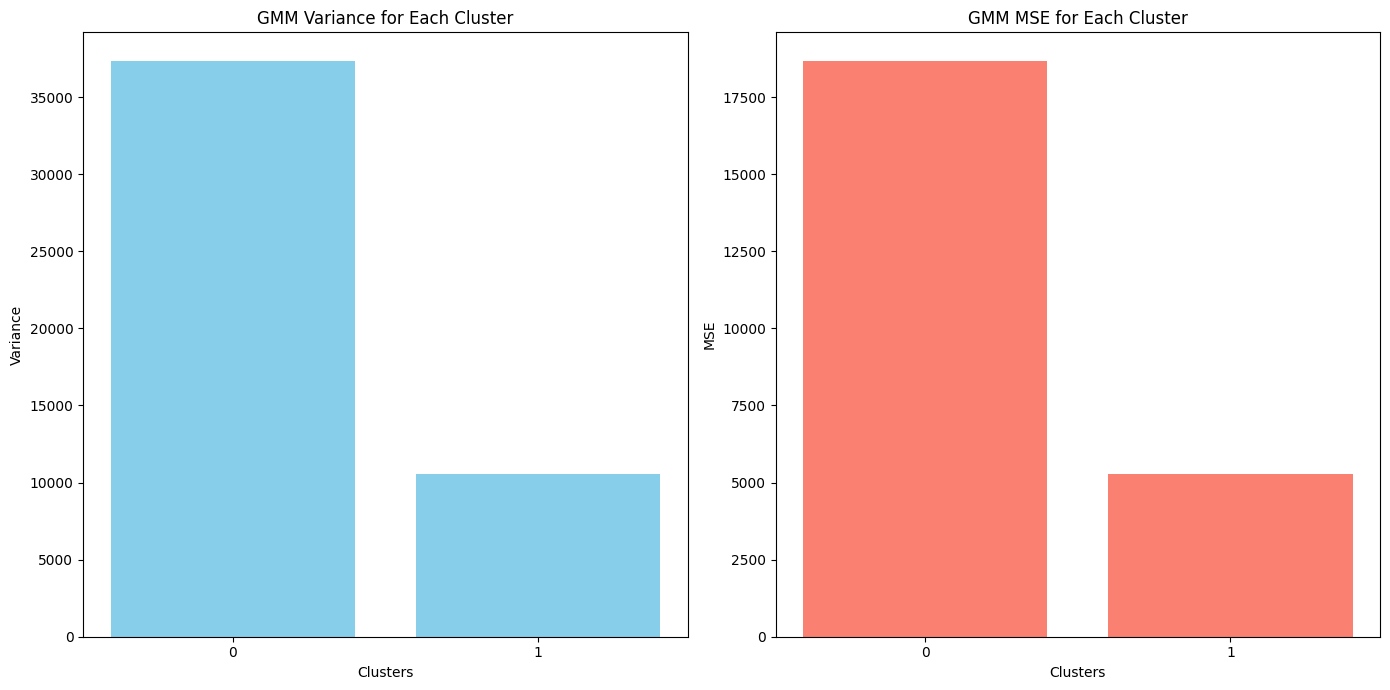

In [11]:
variance_in_minutes = np.sqrt(GMM_variance)
mse_in_minutes = np.sqrt(GMM_mse)

print("Variance in minutes:", variance_in_minutes)
print("MSE in minutes:", mse_in_minutes)
# Plotting
plt.figure(figsize=(12, 6))

# Plot Variance
plt.subplot(1, 2, 1)
plt.bar(range(len(variance_in_minutes)), variance_in_minutes, color='b', alpha=0.7, label='Variance')
plt.xlabel('Clusters')
plt.ylabel('Variance (minutes squared)')
plt.title('GMM Variance by Number of Clusters')
plt.xticks(range(len(variance_in_minutes)))

# Plot MSE
plt.subplot(1, 2, 2)
plt.bar(range(len(mse_in_minutes)), mse_in_minutes, color='r', alpha=0.7, label='MSE')
plt.xlabel('Clusters')
plt.ylabel('MSE (minutes squared)')
plt.title('GMM MSE by Number of Clusters')
plt.xticks(range(len(mse_in_minutes)))

plt.tight_layout()
plt.show()

# Cluster numbers
clusters = np.arange(len(GMM_variance))
# Plotting Variance
plt.figure(figsize=(14, 7))

# Variance Bar Plot
plt.subplot(1, 2, 1)
plt.bar(clusters, GMM_variance, color='skyblue')
plt.xlabel('Clusters')
plt.ylabel('Variance')
plt.title('GMM Variance for Each Cluster')
plt.xticks(clusters)

# MSE Bar Plot
plt.subplot(1, 2, 2)
plt.bar(clusters, GMM_mse, color='salmon')
plt.xlabel('Clusters')
plt.ylabel('MSE')
plt.title('GMM MSE for Each Cluster')
plt.xticks(clusters)

# Show plots
plt.tight_layout()
plt.show()


In [12]:
cluster_summary = DSet.groupby('Cluster').agg({
    'CheckInTime': ['min', 'max'],
    'CheckOutTime': ['min', 'max']
}).reset_index()
# Flatten MultiIndex columns
cluster_summary.columns = ['Cluster', 'CheckInMinutes_Min', 'CheckInMinutes_Max',
                            'CheckOutMinutes_Min', 'CheckOutMinutes_Max']
# Print the summary
# Convert DataFrame to PrettyTable
clusters_table = PrettyTable()
clusters_table.field_names = cluster_summary.columns
for row in cluster_summary.itertuples(index=False):
    clusters_table.add_row(row)
# Print the table
print(clusters_table)

+---------+--------------------+--------------------+---------------------+---------------------+
| Cluster | CheckInMinutes_Min | CheckInMinutes_Max | CheckOutMinutes_Min | CheckOutMinutes_Max |
+---------+--------------------+--------------------+---------------------+---------------------+
|    0    |      06:00:00      |      11:33:00      |       08:46:00      |       18:46:00      |
|    1    |      00:00:00      |      21:22:00      |       02:00:00      |       23:59:00      |
+---------+--------------------+--------------------+---------------------+---------------------+
